# Coarse-grained rotating-drum dataset exploration

## Purpose

This notebook examines the coarse-grained particle volume-fraction fields
generated from the bidisperse rotating-drum simulations.

The objectives are to:

1. identify the available training and test files;
2. extract the particle-size ratio from each filename;
3. inspect and validate the MercuryCG `.stat` file structure;
4. confirm that all snapshots use a consistent spatial grid;
5. extract the coarse-grained volume-fraction field;
6. construct training and test snapshot matrices;
7. visualise representative particle fields;
8. prepare the validated data for POD analysis.

The raw data will not be modified.

In [15]:
from pathlib import Path
import re
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd


def find_project_root(start: Path) -> Path:
    """Locate the repository root from anywhere inside the project."""
    start = start.resolve()

    for candidate in (start, *start.parents):
        required_directories = [
            candidate / "data",
            candidate / "notebooks",
            candidate / "results",
        ]

        if all(path.exists() for path in required_directories):
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root. "
        "Start JupyterLab from the msc-rom-particle-systems repository."
    )


CURRENT_DIR = Path.cwd()
PROJECT_ROOT = find_project_root(CURRENT_DIR)

TRAIN_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "CG_field_phi_small"
)

TEST_DIR = (
    PROJECT_ROOT
    / "data"
    / "raw"
    / "CG_field_phi_small_test_set"
)

FIGURE_DIR = PROJECT_ROOT / "results" / "figures"
TABLE_DIR = PROJECT_ROOT / "results" / "tables"
PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"

for directory in (
    FIGURE_DIR,
    TABLE_DIR,
    PROCESSED_DIR,
):
    directory.mkdir(
        parents=True,
        exist_ok=True,
    )

print("Python executable:", sys.executable)
print("Current directory:", CURRENT_DIR)
print("Project root:", PROJECT_ROOT)
print("Training directory exists:", TRAIN_DIR.exists())
print("Test directory exists:", TEST_DIR.exists())

Python executable: /Users/rallen/Documents/msc-rom-particle-systems/.venv/bin/python
Current directory: /Users/rallen/Documents/msc-rom-particle-systems/notebooks
Project root: /Users/rallen/Documents/msc-rom-particle-systems
Training directory exists: True
Test directory exists: True


In [16]:
# Find all files ending in .stat, including species-specific variants.
all_train_stat_files = sorted(
    TRAIN_DIR.rglob("*.stat")
)

all_test_stat_files = sorted(
    TEST_DIR.rglob("*.stat")
)

# Standard snapshots end exactly with:
# ..._num_<number>.stat
STANDARD_FILE_PATTERN = re.compile(
    r"^rotating_drum_bidisperse_"
    r"size_ratio_\d+_\d+_"
    r"num_\d+\.stat$"
)

train_files = [
    path
    for path in all_train_stat_files
    if STANDARD_FILE_PATTERN.fullmatch(path.name)
]

test_files = [
    path
    for path in all_test_stat_files
    if STANDARD_FILE_PATTERN.fullmatch(path.name)
]

ignored_train_files = [
    path
    for path in all_train_stat_files
    if not STANDARD_FILE_PATTERN.fullmatch(path.name)
]

ignored_test_files = [
    path
    for path in all_test_stat_files
    if not STANDARD_FILE_PATTERN.fullmatch(path.name)
]

if not train_files:
    raise FileNotFoundError(
        f"No standard training .stat files were found in:\n{TRAIN_DIR}"
    )

if not test_files:
    raise FileNotFoundError(
        f"No standard test .stat files were found in:\n{TEST_DIR}"
    )

print("Standard training files:", len(train_files))
print("Standard test files:", len(test_files))

print("\nIgnored training files:", len(ignored_train_files))
for path in ignored_train_files:
    print(" ", path.name)

print("\nIgnored test files:", len(ignored_test_files))
for path in ignored_test_files:
    print(" ", path.name)

print("\nFirst three training files:")
for path in train_files[:3]:
    print(" ", path.name)

print("\nFirst three test files:")
for path in test_files[:3]:
    print(" ", path.name)

Standard training files: 100
Standard test files: 10

Ignored training files: 1
  rotating_drum_bidisperse_size_ratio_1_808081_num_81.largeSpecies.stat

Ignored test files: 0

First three training files:
  rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat
  rotating_drum_bidisperse_size_ratio_1_010101_num_2.stat
  rotating_drum_bidisperse_size_ratio_1_020202_num_3.stat

First three test files:
  rotating_drum_bidisperse_size_ratio_1_062500_num_8.stat
  rotating_drum_bidisperse_size_ratio_1_125000_num_4.stat
  rotating_drum_bidisperse_size_ratio_1_250000_num_2.stat


In [17]:
FILENAME_PATTERN = re.compile(
    r"^rotating_drum_bidisperse_"
    r"size_ratio_"
    r"(?P<integer>\d+)_"
    r"(?P<fraction>\d+)_"
    r"num_(?P<number>\d+)"
    r"\.stat$"
)


def parse_filename(
    path: Path,
) -> tuple[float, int]:
    """
    Extract the size ratio and simulation number.

    Example:
    rotating_drum_bidisperse_size_ratio_1_262626_num_27.stat

    returns:
    size_ratio = 1.262626
    simulation_number = 27
    """
    match = FILENAME_PATTERN.fullmatch(
        path.name
    )

    if match is None:
        raise ValueError(
            "Filename does not match the expected structure:\n"
            f"{path.name}"
        )

    integer_part = match.group(
        "integer"
    )

    fractional_part = match.group(
        "fraction"
    )

    simulation_number = int(
        match.group("number")
    )

    size_ratio = float(
        f"{integer_part}.{fractional_part}"
    )

    return (
        size_ratio,
        simulation_number,
    )


def build_inventory(
    paths: list[Path],
    split: str,
) -> pd.DataFrame:
    """Create a structured table describing the supplied files."""
    records = []

    for path in paths:
        (
            size_ratio,
            simulation_number,
        ) = parse_filename(path)

        records.append(
            {
                "split": split,
                "size_ratio": size_ratio,
                "simulation_number": simulation_number,
                "file_size_mb": (
                    path.stat().st_size
                    / 1024**2
                ),
                "filename": path.name,
                "relative_path": str(
                    path.relative_to(
                        PROJECT_ROOT
                    )
                ),
                "path": path,
            }
        )

    inventory = pd.DataFrame(
        records
    )

    return inventory.sort_values(
        [
            "size_ratio",
            "simulation_number",
        ]
    ).reset_index(
        drop=True
    )


train_inventory = build_inventory(
    train_files,
    split="training",
)

test_inventory = build_inventory(
    test_files,
    split="testing",
)

full_inventory = pd.concat(
    [
        train_inventory,
        test_inventory,
    ],
    ignore_index=True,
)

inventory_for_saving = (
    full_inventory.drop(
        columns="path"
    )
)

inventory_for_saving.to_csv(
    TABLE_DIR
    / "cg_phi_file_inventory.csv",
    index=False,
)

print("Training inventory:")
display(
    train_inventory.head()
)

print("Test inventory:")
display(
    test_inventory.head()
)

Training inventory:


,split,size_ratio,simulation_number,file_size_mb,filename,relative_path,path
0,training,1.000000,1,1.313623,rotating_drum_bidisperse_size_ratio_1_000000_n...,data/raw/CG_field_phi_small/rotating_drum_bidi...,/Users/rallen/Documents/msc-rom-particle-syste...
1,training,1.010101,2,1.316404,rotating_drum_bidisperse_size_ratio_1_010101_n...,data/raw/CG_field_phi_small/rotating_drum_bidi...,/Users/rallen/Documents/msc-rom-particle-syste...
2,training,1.020202,3,1.309952,rotating_drum_bidisperse_size_ratio_1_020202_n...,data/raw/CG_field_phi_small/rotating_drum_bidi...,/Users/rallen/Documents/msc-rom-particle-syste...
3,training,1.030303,4,1.328001,rotating_drum_bidisperse_size_ratio_1_030303_n...,data/raw/CG_field_phi_small/rotating_drum_bidi...,/Users/rallen/Documents/msc-rom-particle-syste...
4,training,1.040404,5,1.315114,rotating_drum_bidisperse_size_ratio_1_040404_n...,data/raw/CG_field_phi_small/rotating_drum_bidi...,/Users/rallen/Documents/msc-rom-particle-syste...


Test inventory:


,split,size_ratio,simulation_number,file_size_mb,filename,relative_path,path
0,testing,1.0625,8,1.316943,rotating_drum_bidisperse_size_ratio_1_062500_n...,data/raw/CG_field_phi_small_test_set/rotating_...,/Users/rallen/Documents/msc-rom-particle-syste...
1,testing,1.1250,4,1.319976,rotating_drum_bidisperse_size_ratio_1_125000_n...,data/raw/CG_field_phi_small_test_set/rotating_...,/Users/rallen/Documents/msc-rom-particle-syste...
2,testing,1.2500,2,1.331956,rotating_drum_bidisperse_size_ratio_1_250000_n...,data/raw/CG_field_phi_small_test_set/rotating_...,/Users/rallen/Documents/msc-rom-particle-syste...
3,testing,1.3125,10,1.341457,rotating_drum_bidisperse_size_ratio_1_312500_n...,data/raw/CG_field_phi_small_test_set/rotating_...,/Users/rallen/Documents/msc-rom-particle-syste...
4,testing,1.3750,6,1.332349,rotating_drum_bidisperse_size_ratio_1_375000_n...,data/raw/CG_field_phi_small_test_set/rotating_...,/Users/rallen/Documents/msc-rom-particle-syste...


Training snapshots: 100
Training unique parameters: 100
Training range: 1.000000 to 2.000000
Training minimum spacing: 0.010101
Training maximum spacing: 0.010102

Testing snapshots: 10
Testing unique parameters: 10
Testing range: 1.062500 to 1.875000
Testing minimum spacing: 0.062500
Testing maximum spacing: 0.125000

Exact train-test parameter overlap:
[]
No exact overlap: all test parameters are unseen.


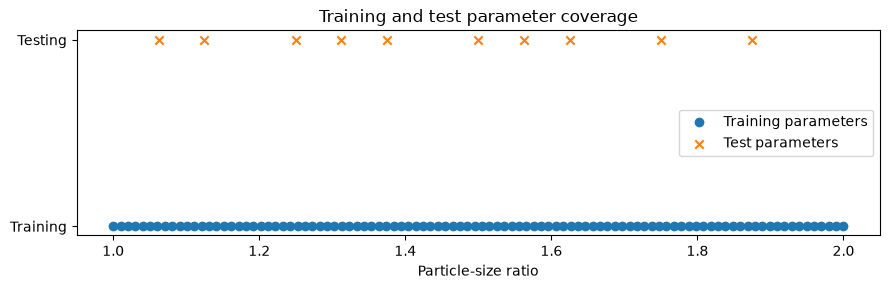

In [18]:
train_parameters = train_inventory[
    "size_ratio"
].to_numpy()

test_parameters = test_inventory[
    "size_ratio"
].to_numpy()


def describe_parameter_set(
    name: str,
    parameters: np.ndarray,
) -> None:
    """Print key information about one parameter set."""
    unique_parameters = np.unique(parameters)

    print(f"{name} snapshots: {parameters.size}")
    print(
        f"{name} unique parameters: "
        f"{unique_parameters.size}"
    )
    print(
        f"{name} range: "
        f"{parameters.min():.6f} to "
        f"{parameters.max():.6f}"
    )

    if unique_parameters.size > 1:
        spacings = np.diff(
            np.sort(unique_parameters)
        )

        print(
            f"{name} minimum spacing: "
            f"{spacings.min():.6f}"
        )
        print(
            f"{name} maximum spacing: "
            f"{spacings.max():.6f}"
        )


describe_parameter_set(
    "Training",
    train_parameters,
)

print()

describe_parameter_set(
    "Testing",
    test_parameters,
)

overlapping_parameters = np.intersect1d(
    train_parameters,
    test_parameters,
)

print("\nExact train-test parameter overlap:")
print(overlapping_parameters)

if overlapping_parameters.size == 0:
    print(
        "No exact overlap: all test parameters are unseen."
    )
else:
    warnings.warn(
        "Some parameter values appear in both training "
        "and test sets."
    )

plt.figure(figsize=(9, 3))

plt.scatter(
    train_parameters,
    np.zeros_like(train_parameters),
    marker="o",
    label="Training parameters",
)

plt.scatter(
    test_parameters,
    np.ones_like(test_parameters),
    marker="x",
    label="Test parameters",
)

plt.yticks(
    [0, 1],
    ["Training", "Testing"],
)

plt.xlabel("Particle-size ratio")
plt.title("Training and test parameter coverage")
plt.legend()
plt.tight_layout()

plt.savefig(
    FIGURE_DIR / "cg_phi_parameter_coverage.pdf",
    bbox_inches="tight",
)

plt.show()

In [19]:
first_training_file = Path(
    train_inventory.iloc[0]["path"]
)

print("Inspecting file:")
print(first_training_file.name)
print()

with first_training_file.open(
    "r",
    encoding="utf-8",
) as handle:
    preview_lines = [
        handle.readline().rstrip()
        for _ in range(5)
    ]

for line_number, line in enumerate(
    preview_lines,
    start=1,
):
    print(f"Line {line_number}:")
    print(line)
    print()

Inspecting file:
rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat

Line 1:
TimeAveragedCG<XZ> min -33 -5 -33 max 33 5 33 timeMin 1377 n 100 1 100 width 3 Lucy cutoff 3

Line 2:
time x z 4:VolumeFraction 5:Density 6-8:Momentum 9-14:MomentumFlux 15-23:ContactStress 24-26:InteractionForce 27-32:ParticleSize

Line 3:
1720.72 -32.67 -32.67 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

Line 4:
1720.72 -32.67 -32.01 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0

Line 5:
1720.72 -32.67 -31.35 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0



In [20]:
def parse_metadata_line(
    metadata_line: str,
) -> dict:
    """Extract key MercuryCG settings from the first line."""
    tokens = metadata_line.split()

    def read_values(
        label: str,
        count: int,
        conversion,
    ) -> tuple:
        if label not in tokens:
            raise ValueError(
                f"Metadata label '{label}' was not found."
            )

        start_index = tokens.index(label) + 1

        return tuple(
            conversion(value)
            for value in tokens[
                start_index:start_index + count
            ]
        )

    return {
        "coarse_graining_type": tokens[0],
        "minimum_coordinates": read_values(
            "min",
            3,
            float,
        ),
        "maximum_coordinates": read_values(
            "max",
            3,
            float,
        ),
        "minimum_averaging_time": read_values(
            "timeMin",
            1,
            float,
        )[0],
        "grid_dimensions": read_values(
            "n",
            3,
            int,
        ),
        "coarse_graining_width": read_values(
            "width",
            1,
            float,
        )[0],
        "cutoff": read_values(
            "cutoff",
            1,
            float,
        )[0],
    }


def load_volume_fraction_field(
    path: Path,
) -> dict:
    """
    Load one coarse-grained volume-fraction field.

    Returns a field with shape (n_z, n_x), where rows correspond
    to z positions and columns correspond to x positions.
    """
    with path.open(
        "r",
        encoding="utf-8",
    ) as handle:
        metadata_line = handle.readline().strip()
        column_header = handle.readline().strip()

    metadata = parse_metadata_line(
        metadata_line
    )

    # Read only:
    # column 1: time
    # column 2: x
    # column 3: z
    # column 4: volume fraction
    values = np.loadtxt(
        path,
        skiprows=2,
        usecols=(0, 1, 2, 3),
        dtype=np.float64,
    )

    values = np.atleast_2d(
        values
    )

    if values.shape[1] != 4:
        raise ValueError(
            f"Unexpected numerical data shape in {path.name}: "
            f"{values.shape}"
        )

    if not np.isfinite(values).all():
        raise ValueError(
            f"Non-finite values were found in {path.name}."
        )

    time_values = np.unique(
        values[:, 0]
    )

    if time_values.size != 1:
        raise ValueError(
            f"{path.name} contains "
            f"{time_values.size} different time values."
        )

    x_values = np.sort(
        np.unique(values[:, 1])
    )

    z_values = np.sort(
        np.unique(values[:, 2])
    )

    number_of_x_points = x_values.size
    number_of_z_points = z_values.size

    expected_number_of_rows = (
        number_of_x_points
        * number_of_z_points
    )

    if values.shape[0] != expected_number_of_rows:
        raise ValueError(
            f"{path.name} has {values.shape[0]} rows, "
            f"but a complete "
            f"{number_of_x_points} by {number_of_z_points} "
            f"grid requires {expected_number_of_rows}."
        )

    x_indices = np.searchsorted(
        x_values,
        values[:, 1],
    )

    z_indices = np.searchsorted(
        z_values,
        values[:, 2],
    )

    coordinate_pairs = np.column_stack(
        [
            z_indices,
            x_indices,
        ]
    )

    number_of_unique_coordinates = np.unique(
        coordinate_pairs,
        axis=0,
    ).shape[0]

    if (
        number_of_unique_coordinates
        != expected_number_of_rows
    ):
        raise ValueError(
            f"Duplicate or missing coordinates were found "
            f"in {path.name}."
        )

    volume_fraction_field = np.full(
        (
            number_of_z_points,
            number_of_x_points,
        ),
        np.nan,
        dtype=np.float64,
    )

    volume_fraction_field[
        z_indices,
        x_indices,
    ] = values[:, 3]

    if not np.isfinite(
        volume_fraction_field
    ).all():
        raise ValueError(
            f"The reconstructed field from {path.name} "
            f"contains missing values."
        )

    metadata_n_x, metadata_n_y, metadata_n_z = (
        metadata["grid_dimensions"]
    )

    if (
        metadata_n_x != number_of_x_points
        or metadata_n_z != number_of_z_points
    ):
        warnings.warn(
            f"Header grid {metadata['grid_dimensions']} "
            f"does not match the coordinate grid "
            f"({number_of_x_points}, 1, {number_of_z_points})."
        )

    return {
        "path": path,
        "metadata": metadata,
        "column_header": column_header,
        "time": float(time_values[0]),
        "x": x_values,
        "z": z_values,
        "field": volume_fraction_field,
    }

In [21]:
representative_index = (
    len(train_inventory) // 2
)

representative_row = train_inventory.iloc[
    representative_index
]

representative_path = Path(
    representative_row["path"]
)

representative_parameter = float(
    representative_row["size_ratio"]
)

representative = load_volume_fraction_field(
    representative_path
)

representative_field = representative[
    "field"
]

x_grid = representative["x"]
z_grid = representative["z"]

print("Filename:")
print(representative_path.name)

print(
    "\nParticle-size ratio:",
    f"{representative_parameter:.6f}",
)

print(
    "Simulation time:",
    representative["time"],
)

print(
    "Field shape:",
    representative_field.shape,
)

print(
    "Number of spatial values:",
    representative_field.size,
)

print(
    "x range:",
    f"{x_grid.min():.4f} to {x_grid.max():.4f}",
)

print(
    "z range:",
    f"{z_grid.min():.4f} to {z_grid.max():.4f}",
)

print(
    "Unique x spacing:",
    np.unique(
        np.round(
            np.diff(x_grid),
            decimals=12,
        )
    ),
)

print(
    "Unique z spacing:",
    np.unique(
        np.round(
            np.diff(z_grid),
            decimals=12,
        )
    ),
)

print(
    "Minimum volume fraction:",
    representative_field.min(),
)

print(
    "Maximum volume fraction:",
    representative_field.max(),
)

print(
    "Mean volume fraction:",
    representative_field.mean(),
)

print(
    "All values finite:",
    np.isfinite(
        representative_field
    ).all(),
)

print("\nMercuryCG metadata:")

for key, value in representative[
    "metadata"
].items():
    print(f"  {key}: {value}")

Filename:
rotating_drum_bidisperse_size_ratio_1_505051_num_51.stat

Particle-size ratio: 1.505051
Simulation time: 1720.72
Field shape: (100, 100)
Number of spatial values: 10000
x range: -32.6700 to 32.6700
z range: -32.6700 to 32.6700
Unique x spacing: [0.66]
Unique z spacing: [0.66]
Minimum volume fraction: 0.0
Maximum volume fraction: 0.523745
Mean volume fraction: 0.0649115630555634
All values finite: True

MercuryCG metadata:
  coarse_graining_type: TimeAveragedCG<XZ>
  minimum_coordinates: (-33.0, -5.0, -33.0)
  maximum_coordinates: (33.0, 5.0, 33.0)
  minimum_averaging_time: 1377.0
  grid_dimensions: (100, 1, 100)
  coarse_graining_width: 3.0
  cutoff: 3.0


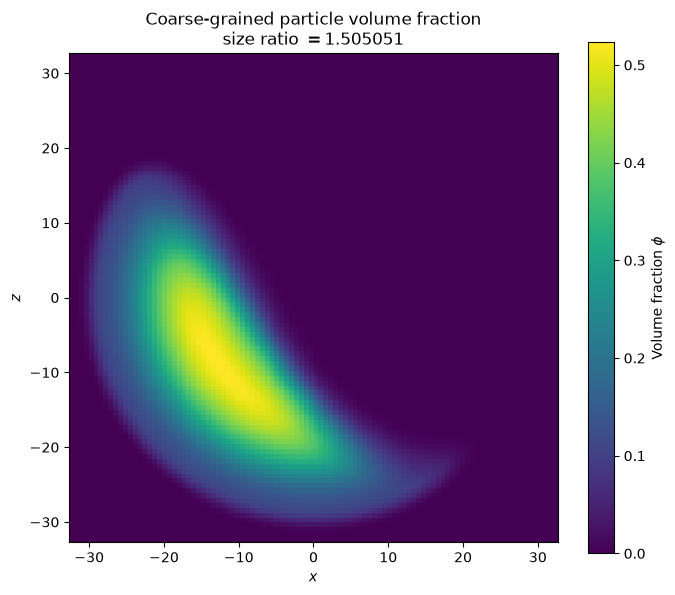

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_representative_snapshot.pdf


In [22]:
fig, axis = plt.subplots(
    figsize=(7, 6)
)

image = axis.imshow(
    representative_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
)

colour_bar = fig.colorbar(
    image,
    ax=axis,
)

colour_bar.set_label(
    r"Volume fraction $\phi$"
)

axis.set_xlabel(r"$x$")
axis.set_ylabel(r"$z$")

axis.set_title(
    "Coarse-grained particle volume fraction\n"
    rf"size ratio $={representative_parameter:.6f}$"
)

fig.tight_layout()

figure_path = (
    FIGURE_DIR
    / "cg_phi_representative_snapshot.pdf"
)

fig.savefig(
    figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(figure_path)

In [23]:
def build_snapshot_matrix(
    inventory: pd.DataFrame,
    reference_x: np.ndarray | None = None,
    reference_z: np.ndarray | None = None,
) -> tuple[
    np.ndarray,
    np.ndarray,
    np.ndarray,
    pd.DataFrame,
]:
    """
    Load all fields in an inventory and stack them as columns.

    Matrix shape:
        number of spatial points × number of simulations
    """
    snapshot_vectors = []
    quality_records = []

    total_files = len(inventory)

    for file_index, row in enumerate(
        inventory.itertuples(index=False),
        start=1,
    ):
        path = Path(row.path)

        loaded = load_volume_fraction_field(
            path
        )

        current_x = loaded["x"]
        current_z = loaded["z"]
        field = loaded["field"]

        if reference_x is None:
            reference_x = current_x.copy()

        if reference_z is None:
            reference_z = current_z.copy()

        if (
            current_x.shape != reference_x.shape
            or not np.allclose(
                current_x,
                reference_x,
            )
        ):
            raise ValueError(
                f"Inconsistent x grid in:\n{path.name}"
            )

        if (
            current_z.shape != reference_z.shape
            or not np.allclose(
                current_z,
                reference_z,
            )
        ):
            raise ValueError(
                f"Inconsistent z grid in:\n{path.name}"
            )

        snapshot_vector = field.reshape(
            -1,
            order="C",
        )

        snapshot_vectors.append(
            snapshot_vector
        )

        quality_records.append(
            {
                "split": row.split,
                "size_ratio": float(
                    row.size_ratio
                ),
                "simulation_number": int(
                    row.simulation_number
                ),
                "time": loaded["time"],
                "n_x": current_x.size,
                "n_z": current_z.size,
                "phi_min": float(
                    field.min()
                ),
                "phi_max": float(
                    field.max()
                ),
                "phi_mean": float(
                    field.mean()
                ),
                "phi_std": float(
                    field.std()
                ),
                "nonzero_fraction": float(
                    np.count_nonzero(field)
                    / field.size
                ),
                "filename": path.name,
            }
        )

        if (
            file_index == 1
            or file_index % 20 == 0
            or file_index == total_files
        ):
            print(
                f"Loaded {file_index}/{total_files}: "
                f"{path.name}"
            )

    snapshot_matrix = np.column_stack(
        snapshot_vectors
    )

    quality_table = pd.DataFrame(
        quality_records
    )

    return (
        snapshot_matrix,
        reference_x,
        reference_z,
        quality_table,
    )


print("Loading training data...")

(
    train_snapshot_matrix,
    x_grid,
    z_grid,
    train_quality,
) = build_snapshot_matrix(
    train_inventory
)

print("\nLoading test data...")

(
    test_snapshot_matrix,
    _,
    _,
    test_quality,
) = build_snapshot_matrix(
    test_inventory,
    reference_x=x_grid,
    reference_z=z_grid,
)

print("\nTraining snapshot matrix shape:")
print(train_snapshot_matrix.shape)

print("\nTest snapshot matrix shape:")
print(test_snapshot_matrix.shape)

Loading training data...
Loaded 1/100: rotating_drum_bidisperse_size_ratio_1_000000_num_1.stat
Loaded 20/100: rotating_drum_bidisperse_size_ratio_1_191919_num_20.stat
Loaded 40/100: rotating_drum_bidisperse_size_ratio_1_393939_num_40.stat
Loaded 60/100: rotating_drum_bidisperse_size_ratio_1_595960_num_60.stat
Loaded 80/100: rotating_drum_bidisperse_size_ratio_1_797980_num_80.stat
Loaded 100/100: rotating_drum_bidisperse_size_ratio_2_000000_num_100.stat

Loading test data...
Loaded 1/10: rotating_drum_bidisperse_size_ratio_1_062500_num_8.stat
Loaded 10/10: rotating_drum_bidisperse_size_ratio_1_875000_num_7.stat

Training snapshot matrix shape:
(10000, 100)

Test snapshot matrix shape:
(10000, 10)


In [24]:
def report_snapshot_dataset(
    name: str,
    snapshot_matrix: np.ndarray,
    quality_table: pd.DataFrame,
) -> None:
    """Print structural and numerical checks for one dataset split."""
    memory_mb = (
        snapshot_matrix.nbytes
        / 1024**2
    )

    print(f"--- {name} ---")
    print(
        "Snapshot matrix shape:",
        snapshot_matrix.shape,
    )
    print(
        "Memory usage:",
        f"{memory_mb:.2f} MB",
    )
    print(
        "All values finite:",
        np.isfinite(
            snapshot_matrix
        ).all(),
    )
    print(
        "Global minimum:",
        snapshot_matrix.min(),
    )
    print(
        "Global maximum:",
        snapshot_matrix.max(),
    )
    print(
        "Global mean:",
        snapshot_matrix.mean(),
    )
    print(
        "Number of distinct times:",
        quality_table[
            "time"
        ].nunique(),
    )
    print(
        "Distinct grid shapes:",
        quality_table[
            ["n_x", "n_z"]
        ].drop_duplicates().to_dict(
            orient="records"
        ),
    )
    print(
        "Mean nonzero spatial fraction:",
        quality_table[
            "nonzero_fraction"
        ].mean(),
    )

    if snapshot_matrix.min() < -1e-12:
        warnings.warn(
            f"{name} contains negative volume fractions."
        )

    if snapshot_matrix.max() > 1.0 + 1e-12:
        warnings.warn(
            f"{name} contains volume fractions greater than one."
        )


report_snapshot_dataset(
    "Training dataset",
    train_snapshot_matrix,
    train_quality,
)

print()

report_snapshot_dataset(
    "Test dataset",
    test_snapshot_matrix,
    test_quality,
)

combined_quality_table = pd.concat(
    [
        train_quality,
        test_quality,
    ],
    ignore_index=True,
)

quality_table_path = (
    TABLE_DIR
    / "cg_phi_quality_summary.csv"
)

combined_quality_table.to_csv(
    quality_table_path,
    index=False,
)

print("\nSaved quality-control table:")
print(quality_table_path)

display(
    combined_quality_table.head()
)

--- Training dataset ---
Snapshot matrix shape: (10000, 100)
Memory usage: 7.63 MB
All values finite: True
Global minimum: 0.0
Global maximum: 0.540123
Global mean: 0.06491234162488779
Number of distinct times: 1
Distinct grid shapes: [{'n_x': 100, 'n_z': 100}]
Mean nonzero spatial fraction: 0.43036100000000005

--- Test dataset ---
Snapshot matrix shape: (10000, 10)
Memory usage: 0.76 MB
All values finite: True
Global minimum: 0.0
Global maximum: 0.536825
Global mean: 0.06491168587552315
Number of distinct times: 1
Distinct grid shapes: [{'n_x': 100, 'n_z': 100}]
Mean nonzero spatial fraction: 0.42721

Saved quality-control table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_quality_summary.csv


,split,size_ratio,simulation_number,time,n_x,n_z,phi_min,phi_max,phi_mean,phi_std,nonzero_fraction,filename
0,training,1.000000,1,1720.72,100,100,0.0,0.298251,0.064922,0.107221,0.4121,rotating_drum_bidisperse_size_ratio_1_000000_n...
1,training,1.010101,2,1720.72,100,100,0.0,0.304087,0.064915,0.107110,0.4139,rotating_drum_bidisperse_size_ratio_1_010101_n...
2,training,1.020202,3,1720.72,100,100,0.0,0.307991,0.064912,0.107461,0.4102,rotating_drum_bidisperse_size_ratio_1_020202_n...
3,training,1.030303,4,1720.72,100,100,0.0,0.313504,0.064915,0.107288,0.4213,rotating_drum_bidisperse_size_ratio_1_030303_n...
4,training,1.040404,5,1720.72,100,100,0.0,0.328202,0.064918,0.107881,0.4130,rotating_drum_bidisperse_size_ratio_1_040404_n...


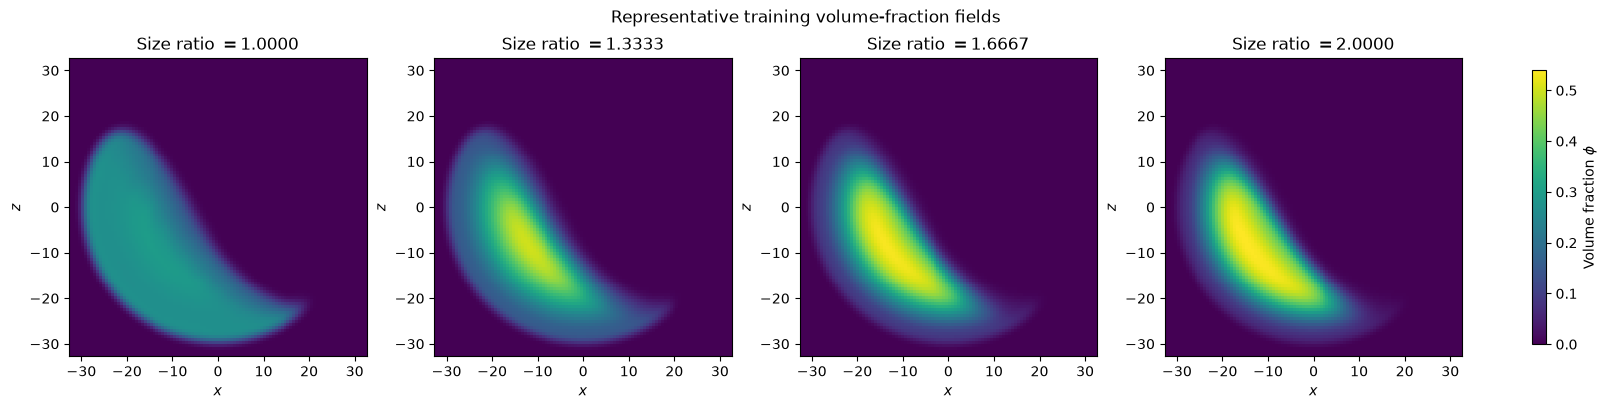

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_training_snapshots.pdf


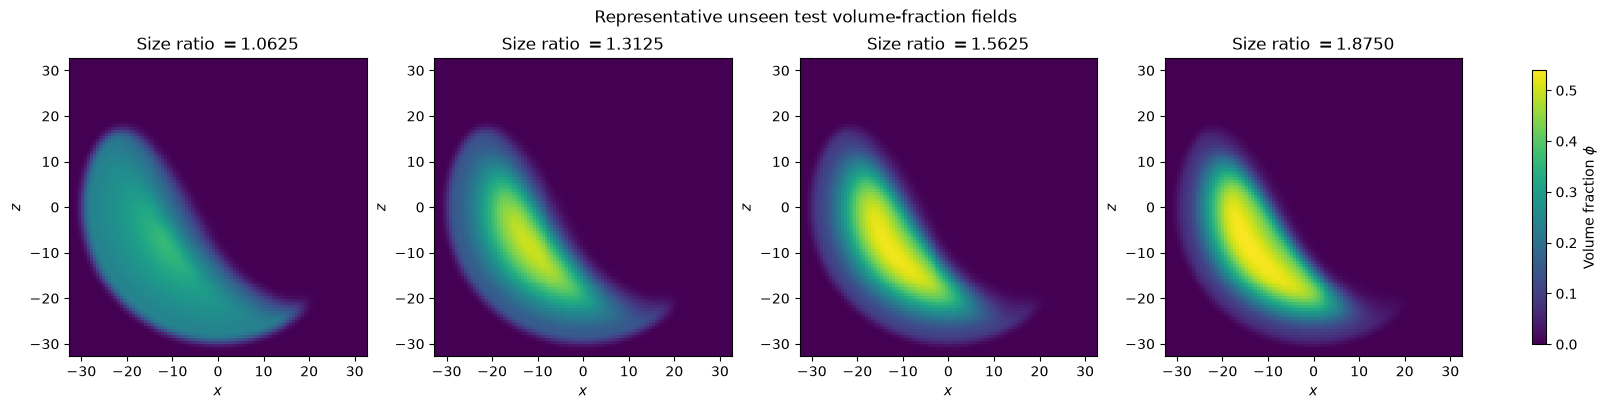

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_test_snapshots.pdf


In [25]:
global_maximum_volume_fraction = max(
    train_snapshot_matrix.max(),
    test_snapshot_matrix.max(),
)


def plot_snapshot_montage(
    snapshot_matrix: np.ndarray,
    parameters: np.ndarray,
    title: str,
    output_filename: str,
    number_of_panels: int = 4,
) -> None:
    """Plot evenly spaced snapshots from one dataset split."""
    number_of_snapshots = (
        snapshot_matrix.shape[1]
    )

    number_of_panels = min(
        number_of_panels,
        number_of_snapshots,
    )

    selected_indices = np.unique(
        np.linspace(
            0,
            number_of_snapshots - 1,
            number_of_panels,
        ).round().astype(int)
    )

    figure, axes = plt.subplots(
        1,
        len(selected_indices),
        figsize=(
            4 * len(selected_indices),
            4,
        ),
        constrained_layout=True,
        squeeze=False,
    )

    axes = axes.ravel()

    for axis, snapshot_index in zip(
        axes,
        selected_indices,
    ):
        field = snapshot_matrix[
            :,
            snapshot_index,
        ].reshape(
            len(z_grid),
            len(x_grid),
            order="C",
        )

        image = axis.imshow(
            field,
            origin="lower",
            extent=(
                x_grid.min(),
                x_grid.max(),
                z_grid.min(),
                z_grid.max(),
            ),
            aspect="equal",
            interpolation="nearest",
            vmin=0.0,
            vmax=global_maximum_volume_fraction,
        )

        axis.set_title(
            rf"Size ratio $={parameters[snapshot_index]:.4f}$"
        )

        axis.set_xlabel(r"$x$")
        axis.set_ylabel(r"$z$")

    colour_bar = figure.colorbar(
        image,
        ax=axes.tolist(),
        shrink=0.82,
    )

    colour_bar.set_label(
        r"Volume fraction $\phi$"
    )

    figure.suptitle(
        title
    )

    output_path = (
        FIGURE_DIR
        / output_filename
    )

    figure.savefig(
        output_path,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved figure:")
    print(output_path)


plot_snapshot_montage(
    train_snapshot_matrix,
    train_parameters,
    title="Representative training volume-fraction fields",
    output_filename="cg_phi_training_snapshots.pdf",
)

plot_snapshot_montage(
    test_snapshot_matrix,
    test_parameters,
    title="Representative unseen test volume-fraction fields",
    output_filename="cg_phi_test_snapshots.pdf",
)

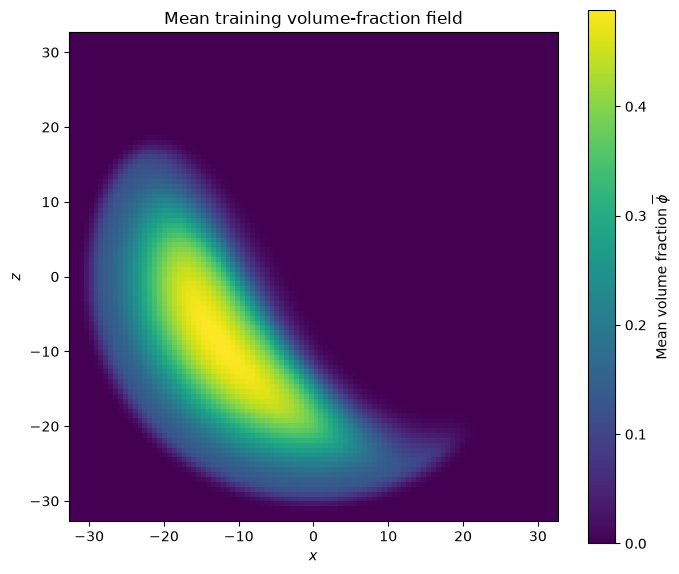

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_training_mean.pdf


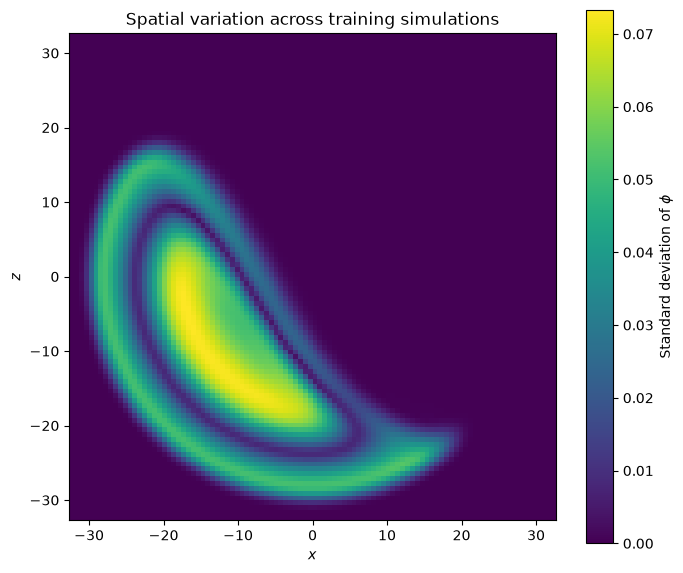

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_training_standard_deviation.pdf

Maximum spatial standard deviation: 0.07332600993535376
Location of maximum variation: (-17.49, -3.63)


In [26]:
mean_training_field = (
    train_snapshot_matrix
       .mean(axis=1)
    .reshape(
        len(z_grid),
        len(x_grid),
        order="C",
    )
)

standard_deviation_field = (
    train_snapshot_matrix
    .std(axis=1)
    .reshape(
        len(z_grid),
        len(x_grid),
        order="C",
    )
)


def plot_spatial_field(
    field: np.ndarray,
    title: str,
    colour_bar_label: str,
    output_filename: str,
    minimum_value: float | None = None,
) -> None:
    """Plot and save one spatial field."""
    figure, axis = plt.subplots(
        figsize=(7, 6)
    )

    image = axis.imshow(
        field,
        origin="lower",
        extent=(
            x_grid.min(),
            x_grid.max(),
            z_grid.min(),
            z_grid.max(),
        ),
        aspect="equal",
        interpolation="nearest",
        vmin=minimum_value,
    )

    colour_bar = figure.colorbar(
        image,
        ax=axis,
    )

    colour_bar.set_label(
        colour_bar_label
    )

    axis.set_xlabel(r"$x$")
    axis.set_ylabel(r"$z$")
    axis.set_title(title)

    figure.tight_layout()

    output_path = (
        FIGURE_DIR
        / output_filename
    )

    figure.savefig(
        output_path,
        bbox_inches="tight",
    )

    plt.show()

    print("Saved figure:")
    print(output_path)


plot_spatial_field(
    mean_training_field,
    title="Mean training volume-fraction field",
    colour_bar_label=r"Mean volume fraction $\overline{\phi}$",
    output_filename="cg_phi_training_mean.pdf",
    minimum_value=0.0,
)

plot_spatial_field(
    standard_deviation_field,
    title="Spatial variation across training simulations",
    colour_bar_label=r"Standard deviation of $\phi$",
    output_filename="cg_phi_training_standard_deviation.pdf",
    minimum_value=0.0,
)

print(
    "\nMaximum spatial standard deviation:",
    standard_deviation_field.max(),
)

maximum_variation_index = np.unravel_index(
    np.argmax(standard_deviation_field),
    standard_deviation_field.shape,
)

print(
    "Location of maximum variation:",
    (
        x_grid[maximum_variation_index[1]],
        z_grid[maximum_variation_index[0]],
    ),
)

In [27]:
processed_dataset_path = (
    PROCESSED_DIR
    / "cg_phi_small_dataset.npz"
)

np.savez_compressed(
    processed_dataset_path,
    x=x_grid,
    z=z_grid,
    train_parameters=train_parameters,
    test_parameters=test_parameters,
    train_simulation_numbers=(
        train_inventory[
            "simulation_number"
        ].to_numpy(dtype=int)
    ),
    test_simulation_numbers=(
        test_inventory[
            "simulation_number"
        ].to_numpy(dtype=int)
    ),
    train_filenames=(
        train_inventory[
            "filename"
        ].to_numpy(dtype=str)
    ),
    test_filenames=(
        test_inventory[
            "filename"
        ].to_numpy(dtype=str)
    ),
    train_snapshots=train_snapshot_matrix,
    test_snapshots=test_snapshot_matrix,
)

print("Saved processed dataset:")
print(processed_dataset_path)

print(
    "Compressed file size:",
    f"{processed_dataset_path.stat().st_size / 1024**2:.2f} MB",
)

# Verify that the saved file can be reopened.
with np.load(
    processed_dataset_path,
    allow_pickle=False,
) as saved_data:
    print("\nSaved arrays:")

    for array_name in saved_data.files:
        print(
            f"  {array_name}: "
            f"{saved_data[array_name].shape}"
        )

    assert np.array_equal(
        saved_data["train_parameters"],
        train_parameters,
    )

    assert np.array_equal(
        saved_data["test_parameters"],
        test_parameters,
    )

    assert np.allclose(
        saved_data["train_snapshots"],
        train_snapshot_matrix,
    )

    assert np.allclose(
        saved_data["test_snapshots"],
        test_snapshot_matrix,
    )

print("\nProcessed dataset verification passed.")

Saved processed dataset:
/Users/rallen/Documents/msc-rom-particle-systems/data/processed/cg_phi_small_dataset.npz
Compressed file size: 3.25 MB

Saved arrays:
  x: (100,)
  z: (100,)
  train_parameters: (100,)
  test_parameters: (10,)
  train_simulation_numbers: (100,)
  test_simulation_numbers: (10,)
  train_filenames: (100,)
  test_filenames: (10,)
  train_snapshots: (10000, 100)
  test_snapshots: (10000, 10)

Processed dataset verification passed.


In [28]:
# Uncentred POD uses the physical fields directly.
(
    uncentred_modes,
    uncentred_singular_values,
    uncentred_right_vectors,
) = np.linalg.svd(
    train_snapshot_matrix,
    full_matrices=False,
)

# Mean-centred POD represents deviations from the average field.
mean_snapshot_vector = train_snapshot_matrix.mean(
    axis=1,
    keepdims=True,
)

centred_training_matrix = (
    train_snapshot_matrix
    - mean_snapshot_vector
)

(
    centred_modes,
    centred_singular_values,
    centred_right_vectors,
) = np.linalg.svd(
    centred_training_matrix,
    full_matrices=False,
)


def cumulative_pod_energy(
    singular_values: np.ndarray,
) -> np.ndarray:
    """Calculate cumulative energy from squared singular values."""
    squared_values = singular_values**2
    total_energy = squared_values.sum()

    if total_energy <= 0.0:
        raise ValueError(
            "The snapshot matrix has zero total energy."
        )

    return np.cumsum(
        squared_values
    ) / total_energy


def rank_for_energy_threshold(
    cumulative_energy: np.ndarray,
    threshold: float,
) -> int:
    """Return the smallest rank reaching the requested energy."""
    return int(
        np.searchsorted(
            cumulative_energy,
            threshold,
        )
        + 1
    )


uncentred_energy = cumulative_pod_energy(
    uncentred_singular_values
)

centred_energy = cumulative_pod_energy(
    centred_singular_values
)

energy_thresholds = [
    0.90,
    0.95,
    0.99,
    0.999,
]

uncentred_ranks = {
    threshold: rank_for_energy_threshold(
        uncentred_energy,
        threshold,
    )
    for threshold in energy_thresholds
}

centred_ranks = {
    threshold: rank_for_energy_threshold(
        centred_energy,
        threshold,
    )
    for threshold in energy_thresholds
}

print("Uncentred POD:")
for threshold, rank in uncentred_ranks.items():
    print(
        f"  {100 * threshold:.1f}% energy: "
        f"{rank} modes"
    )

print("\nMean-centred POD:")
for threshold, rank in centred_ranks.items():
    print(
        f"  {100 * threshold:.1f}% energy: "
        f"{rank} modes"
    )

print("\nFirst ten uncentred singular values:")
print(
    uncentred_singular_values[:10]
)

print("\nFirst ten centred singular values:")
print(
    centred_singular_values[:10]
)

Uncentred POD:
  90.0% energy: 1 modes
  95.0% energy: 1 modes
  99.0% energy: 2 modes
  99.9% energy: 2 modes

Mean-centred POD:
  90.0% energy: 1 modes
  95.0% energy: 1 modes
  99.0% energy: 2 modes
  99.9% energy: 6 modes

First ten uncentred singular values:
[140.93976841  18.93875337   3.97002634   0.80323767   0.500821
   0.36222039   0.30541509   0.28121312   0.26750783   0.1963371 ]

First ten centred singular values:
[21.57580836  3.97089964  0.80571066  0.5036125   0.36391025  0.30582639
  0.28203814  0.26750887  0.19638002  0.16599938]


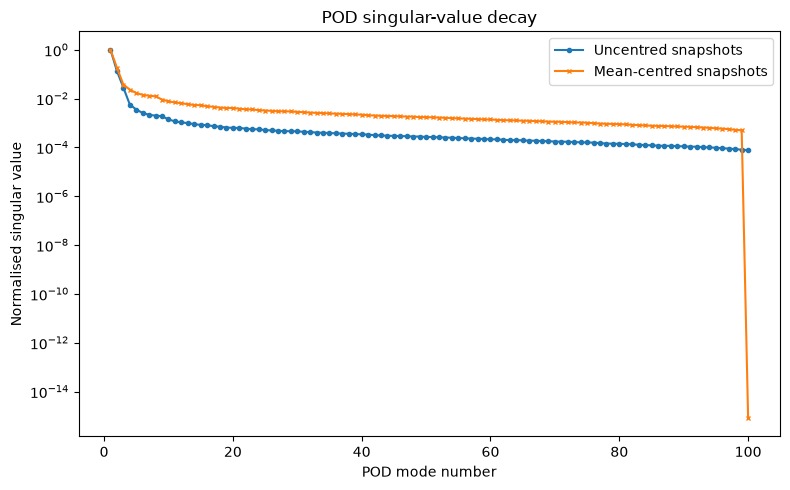

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_singular_value_decay.pdf


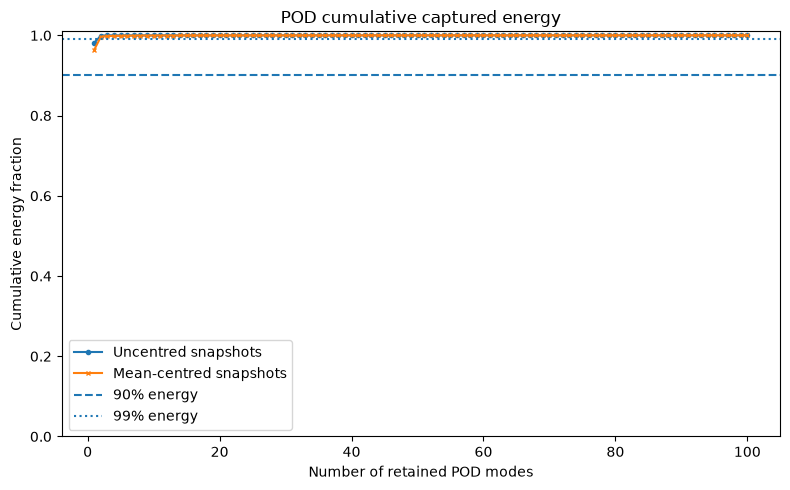

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_cumulative_energy.pdf


In [30]:
uncentred_mode_numbers = np.arange(
    1,
    uncentred_singular_values.size + 1,
)

centred_mode_numbers = np.arange(
    1,
    centred_singular_values.size + 1,
)


# Singular-value decay
plt.figure(figsize=(8, 5))

plt.semilogy(
    uncentred_mode_numbers,
    (
        uncentred_singular_values
        / uncentred_singular_values[0]
    ),
    marker="o",
    markersize=3,
    label="Uncentred snapshots",
)

plt.semilogy(
    centred_mode_numbers,
    (
        centred_singular_values
        / centred_singular_values[0]
    ),
    marker="x",
    markersize=3,
    label="Mean-centred snapshots",
)

plt.xlabel("POD mode number")
plt.ylabel("Normalised singular value")
plt.title("POD singular-value decay")
plt.legend()
plt.tight_layout()

singular_value_figure_path = (
    FIGURE_DIR
    / "cg_phi_singular_value_decay.pdf"
)

plt.savefig(
    singular_value_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(singular_value_figure_path)


# Cumulative energy
plt.figure(figsize=(8, 5))

plt.plot(
    uncentred_mode_numbers,
    uncentred_energy,
    marker="o",
    markersize=3,
    label="Uncentred snapshots",
)

plt.plot(
    centred_mode_numbers,
    centred_energy,
    marker="x",
    markersize=3,
    label="Mean-centred snapshots",
)

plt.axhline(
    0.90,
    linestyle="--",
    label="90% energy",
)

plt.axhline(
    0.99,
    linestyle=":",
    label="99% energy",
)

plt.xlabel("Number of retained POD modes")
plt.ylabel("Cumulative energy fraction")
plt.title("POD cumulative captured energy")
plt.ylim(0.0, 1.01)
plt.legend()
plt.tight_layout()

energy_figure_path = (
    FIGURE_DIR
    / "cg_phi_cumulative_energy.pdf"
)

plt.savefig(
    energy_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(energy_figure_path)

In [31]:
def calculate_projection_errors(
    snapshot_matrix: np.ndarray,
    modes: np.ndarray,
    offset: np.ndarray | None = None,
    maximum_rank: int = 30,
) -> tuple[np.ndarray, np.ndarray]:
    """
    Calculate mean and maximum relative projection errors by POD rank.

    If offset is supplied, the POD basis acts on fluctuations around
    that offset. For mean-centred POD, offset is the training mean field.
    """
    maximum_rank = min(
        maximum_rank,
        modes.shape[1],
    )

    if offset is None:
        shifted_snapshots = snapshot_matrix
    else:
        shifted_snapshots = (
            snapshot_matrix - offset
        )

    retained_modes = modes[
        :,
        :maximum_rank,
    ]

    coefficients = (
        retained_modes.T
        @ shifted_snapshots
    )

    shifted_norm_squared = np.sum(
        shifted_snapshots**2,
        axis=0,
    )

    captured_energy = np.cumsum(
        coefficients**2,
        axis=0,
    )

    residual_energy = np.maximum(
        shifted_norm_squared[None, :]
        - captured_energy,
        0.0,
    )

    # Errors are measured relative to the complete physical test field.
    reference_norm_squared = np.sum(
        snapshot_matrix**2,
        axis=0,
    )

    reference_norm_squared = np.maximum(
        reference_norm_squared,
        np.finfo(float).tiny,
    )

    relative_errors = np.sqrt(
        residual_energy
        / reference_norm_squared[None, :]
    )

    mean_errors = relative_errors.mean(
        axis=1
    )

    maximum_errors = relative_errors.max(
        axis=1
    )

    return (
        mean_errors,
        maximum_errors,
    )


maximum_test_rank = min(
    30,
    train_snapshot_matrix.shape[1],
)

(
    uncentred_mean_test_errors,
    uncentred_maximum_test_errors,
) = calculate_projection_errors(
    snapshot_matrix=test_snapshot_matrix,
    modes=uncentred_modes,
    offset=None,
    maximum_rank=maximum_test_rank,
)

(
    centred_mean_test_errors,
    centred_maximum_test_errors,
) = calculate_projection_errors(
    snapshot_matrix=test_snapshot_matrix,
    modes=centred_modes,
    offset=mean_snapshot_vector,
    maximum_rank=maximum_test_rank,
)

projection_ranks = np.arange(
    1,
    maximum_test_rank + 1,
)

print(
    "Projection errors calculated for ranks "
    f"1 to {maximum_test_rank}."
)

Projection errors calculated for ranks 1 to 30.


Uncentred POD test errors:
  Rank  1: mean = 1.123908e-01, maximum = 2.987245e-01
  Rank  2: mean = 2.459688e-02, maximum = 3.830992e-02
  Rank  3: mean = 7.921946e-03, maximum = 1.240173e-02
  Rank  5: mean = 5.577256e-03, maximum = 8.011516e-03
  Rank  6: mean = 5.333209e-03, maximum = 7.298099e-03
  Rank 10: mean = 4.116677e-03, maximum = 6.391114e-03
  Rank 30: mean = 2.934467e-03, maximum = 4.210201e-03

Mean-centred POD test errors:
  Rank  1: mean = 2.461135e-02, maximum = 3.827531e-02
  Rank  2: mean = 7.940739e-03, maximum = 1.240508e-02
  Rank  3: mean = 6.311065e-03, maximum = 1.138373e-02
  Rank  5: mean = 5.343268e-03, maximum = 7.310726e-03
  Rank  6: mean = 5.034892e-03, maximum = 7.215174e-03
  Rank 10: mean = 4.033258e-03, maximum = 6.155665e-03
  Rank 30: mean = 2.916812e-03, maximum = 4.170224e-03


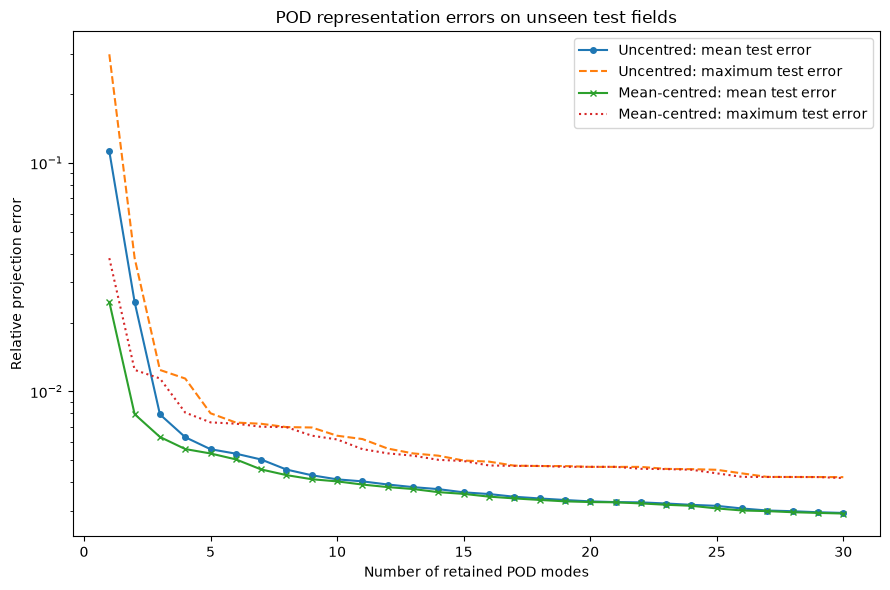


Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_test_projection_errors.pdf


In [32]:
candidate_ranks = sorted(
    {
        1,
        2,
        3,
        5,
        6,
        10,
        maximum_test_rank,
    }
)

candidate_ranks = [
    rank
    for rank in candidate_ranks
    if rank <= maximum_test_rank
]

print("Uncentred POD test errors:")

for rank in candidate_ranks:
    print(
        f"  Rank {rank:2d}: "
        f"mean = "
        f"{uncentred_mean_test_errors[rank - 1]:.6e}, "
        f"maximum = "
        f"{uncentred_maximum_test_errors[rank - 1]:.6e}"
    )

print("\nMean-centred POD test errors:")

for rank in candidate_ranks:
    print(
        f"  Rank {rank:2d}: "
        f"mean = "
        f"{centred_mean_test_errors[rank - 1]:.6e}, "
        f"maximum = "
        f"{centred_maximum_test_errors[rank - 1]:.6e}"
    )


plt.figure(figsize=(9, 6))

plt.semilogy(
    projection_ranks,
    uncentred_mean_test_errors,
    marker="o",
    markersize=4,
    label="Uncentred: mean test error",
)

plt.semilogy(
    projection_ranks,
    uncentred_maximum_test_errors,
    linestyle="--",
    label="Uncentred: maximum test error",
)

plt.semilogy(
    projection_ranks,
    centred_mean_test_errors,
    marker="x",
    markersize=4,
    label="Mean-centred: mean test error",
)

plt.semilogy(
    projection_ranks,
    centred_maximum_test_errors,
    linestyle=":",
    label="Mean-centred: maximum test error",
)

plt.xlabel("Number of retained POD modes")
plt.ylabel("Relative projection error")
plt.title(
    "POD representation errors on unseen test fields"
)
plt.legend()
plt.tight_layout()

test_error_figure_path = (
    FIGURE_DIR
    / "cg_phi_test_projection_errors.pdf"
)

plt.savefig(
    test_error_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved figure:")
print(test_error_figure_path)

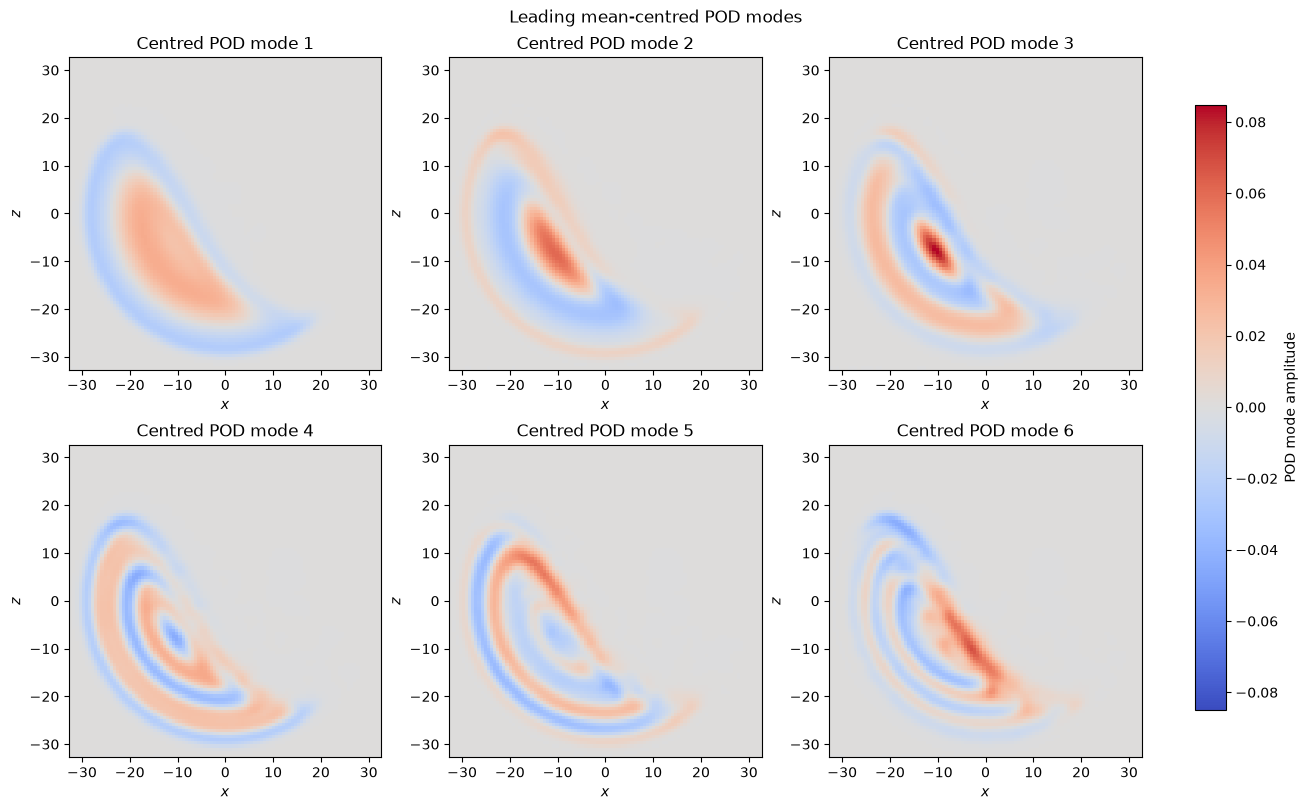

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_centred_pod_modes.pdf


In [33]:
number_of_modes_to_plot = 6

figure, axes = plt.subplots(
    2,
    3,
    figsize=(13, 8),
    constrained_layout=True,
)

axes = axes.ravel()

maximum_absolute_mode_value = np.max(
    np.abs(
        centred_modes[
            :,
            :number_of_modes_to_plot,
        ]
    )
)

for mode_index, axis in enumerate(axes):
    mode_field = centred_modes[
        :,
        mode_index,
    ].reshape(
        len(z_grid),
        len(x_grid),
        order="C",
    )

    image = axis.imshow(
        mode_field,
        origin="lower",
        extent=(
            x_grid.min(),
            x_grid.max(),
            z_grid.min(),
            z_grid.max(),
        ),
        aspect="equal",
        interpolation="nearest",
        cmap="coolwarm",
        vmin=-maximum_absolute_mode_value,
        vmax=maximum_absolute_mode_value,
    )

    axis.set_title(
        f"Centred POD mode {mode_index + 1}"
    )
    axis.set_xlabel(r"$x$")
    axis.set_ylabel(r"$z$")

colour_bar = figure.colorbar(
    image,
    ax=axes.tolist(),
    shrink=0.85,
)

colour_bar.set_label("POD mode amplitude")

figure.suptitle(
    "Leading mean-centred POD modes"
)

mode_figure_path = (
    FIGURE_DIR
    / "cg_phi_centred_pod_modes.pdf"
)

figure.savefig(
    mode_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(mode_figure_path)

Selected rank: 6
Worst test parameter: 1.125000
Worst relative projection error: 7.215174e-03


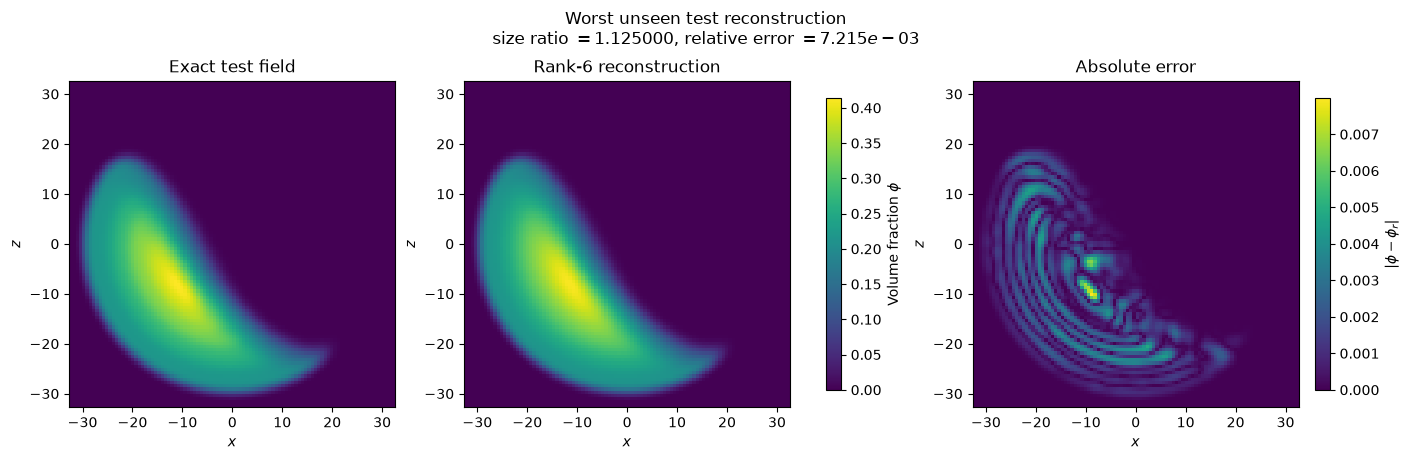


Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_worst_test_reconstruction_rank6.pdf


In [34]:
selected_rank = 6

selected_modes = centred_modes[
    :,
    :selected_rank,
]

centred_test_snapshots = (
    test_snapshot_matrix
    - mean_snapshot_vector
)

selected_coefficients = (
    selected_modes.T
    @ centred_test_snapshots
)

reconstructed_test_snapshots = (
    mean_snapshot_vector
    + selected_modes
    @ selected_coefficients
)

relative_errors_at_selected_rank = (
    np.linalg.norm(
        test_snapshot_matrix
        - reconstructed_test_snapshots,
        axis=0,
    )
    / np.linalg.norm(
        test_snapshot_matrix,
        axis=0,
    )
)

worst_test_index = int(
    np.argmax(
        relative_errors_at_selected_rank
    )
)

worst_parameter = test_parameters[
    worst_test_index
]

exact_field = test_snapshot_matrix[
    :,
    worst_test_index,
].reshape(
    len(z_grid),
    len(x_grid),
    order="C",
)

reconstructed_field = (
    reconstructed_test_snapshots[
        :,
        worst_test_index,
    ].reshape(
        len(z_grid),
        len(x_grid),
        order="C",
    )
)

absolute_error_field = np.abs(
    exact_field
    - reconstructed_field
)

print(
    "Selected rank:",
    selected_rank,
)

print(
    "Worst test parameter:",
    f"{worst_parameter:.6f}",
)

print(
    "Worst relative projection error:",
    f"{relative_errors_at_selected_rank[worst_test_index]:.6e}",
)

figure, axes = plt.subplots(
    1,
    3,
    figsize=(14, 4.5),
    constrained_layout=True,
)

physical_vmax = max(
    exact_field.max(),
    reconstructed_field.max(),
)

exact_image = axes[0].imshow(
    exact_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
    vmax=physical_vmax,
)

axes[0].set_title("Exact test field")
axes[0].set_xlabel(r"$x$")
axes[0].set_ylabel(r"$z$")

axes[1].imshow(
    reconstructed_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
    vmax=physical_vmax,
)

axes[1].set_title(
    f"Rank-{selected_rank} reconstruction"
)
axes[1].set_xlabel(r"$x$")
axes[1].set_ylabel(r"$z$")

error_image = axes[2].imshow(
    absolute_error_field,
    origin="lower",
    extent=(
        x_grid.min(),
        x_grid.max(),
        z_grid.min(),
        z_grid.max(),
    ),
    aspect="equal",
    interpolation="nearest",
    vmin=0.0,
)

axes[2].set_title("Absolute error")
axes[2].set_xlabel(r"$x$")
axes[2].set_ylabel(r"$z$")

physical_colour_bar = figure.colorbar(
    exact_image,
    ax=axes[:2].tolist(),
    shrink=0.82,
)

physical_colour_bar.set_label(
    r"Volume fraction $\phi$"
)

error_colour_bar = figure.colorbar(
    error_image,
    ax=axes[2],
    shrink=0.82,
)

error_colour_bar.set_label(
    r"$|\phi-\phi_r|$"
)

figure.suptitle(
    "Worst unseen test reconstruction\n"
    rf"size ratio $={worst_parameter:.6f}$, "
    rf"relative error $="
    rf"{relative_errors_at_selected_rank[worst_test_index]:.3e}$"
)

reconstruction_figure_path = (
    FIGURE_DIR
    / "cg_phi_worst_test_reconstruction_rank6.pdf"
)

figure.savefig(
    reconstruction_figure_path,
    bbox_inches="tight",
)

plt.show()

print("\nSaved figure:")
print(reconstruction_figure_path)

In [35]:
x_spacing = float(
    np.mean(
        np.diff(x_grid)
    )
)

z_spacing = float(
    np.mean(
        np.diff(z_grid)
    )
)

grid_cell_area = (
    x_spacing
    * z_spacing
)

diagnostic_records = []

for test_index, parameter in enumerate(
    test_parameters
):
    exact_snapshot = test_snapshot_matrix[
        :,
        test_index,
    ]

    reconstructed_snapshot = (
        reconstructed_test_snapshots[
            :,
            test_index,
        ]
    )

    relative_field_error = (
        np.linalg.norm(
            exact_snapshot
            - reconstructed_snapshot
        )
        / np.linalg.norm(
            exact_snapshot
        )
    )

    exact_integrated_volume = (
        exact_snapshot.sum()
        * grid_cell_area
    )

    reconstructed_integrated_volume = (
        reconstructed_snapshot.sum()
        * grid_cell_area
    )

    relative_volume_error = (
        abs(
            reconstructed_integrated_volume
            - exact_integrated_volume
        )
        / abs(
            exact_integrated_volume
        )
    )

    diagnostic_records.append(
        {
            "size_ratio": parameter,
            "relative_field_error": (
                relative_field_error
            ),
            "exact_integrated_volume": (
                exact_integrated_volume
            ),
            "reconstructed_integrated_volume": (
                reconstructed_integrated_volume
            ),
            "relative_volume_error": (
                relative_volume_error
            ),
            "reconstructed_minimum": float(
                reconstructed_snapshot.min()
            ),
            "reconstructed_maximum": float(
                reconstructed_snapshot.max()
            ),
            "negative_value_fraction": float(
                np.mean(
                    reconstructed_snapshot < 0.0
                )
            ),
            "above_one_fraction": float(
                np.mean(
                    reconstructed_snapshot > 1.0
                )
            ),
        }
    )

rank_six_diagnostics = pd.DataFrame(
    diagnostic_records
)

diagnostic_table_path = (
    TABLE_DIR
    / "cg_phi_rank6_test_diagnostics.csv"
)

rank_six_diagnostics.to_csv(
    diagnostic_table_path,
    index=False,
)

print("Rank-6 test reconstruction diagnostics")
print("--------------------------------------")

print(
    "Mean relative field error:",
    f"{rank_six_diagnostics['relative_field_error'].mean():.6e}",
)

print(
    "Maximum relative field error:",
    f"{rank_six_diagnostics['relative_field_error'].max():.6e}",
)

print(
    "Mean relative volume error:",
    f"{rank_six_diagnostics['relative_volume_error'].mean():.6e}",
)

print(
    "Maximum relative volume error:",
    f"{rank_six_diagnostics['relative_volume_error'].max():.6e}",
)

print(
    "Minimum reconstructed value:",
    f"{rank_six_diagnostics['reconstructed_minimum'].min():.6e}",
)

print(
    "Maximum reconstructed value:",
    f"{rank_six_diagnostics['reconstructed_maximum'].max():.6e}",
)

print(
    "Largest fraction of negative grid values:",
    f"{rank_six_diagnostics['negative_value_fraction'].max():.6e}",
)

print(
    "Largest fraction of values above one:",
    f"{rank_six_diagnostics['above_one_fraction'].max():.6e}",
)

print("\nSaved diagnostics table:")
print(diagnostic_table_path)

display(
    rank_six_diagnostics
)

Rank-6 test reconstruction diagnostics
--------------------------------------
Mean relative field error: 5.034892e-03
Maximum relative field error: 7.215174e-03
Mean relative volume error: 2.776233e-05
Maximum relative volume error: 8.643004e-05
Minimum reconstructed value: -1.165410e-05
Maximum reconstructed value: 5.374684e-01
Largest fraction of negative grid values: 5.770000e-02
Largest fraction of values above one: 0.000000e+00

Saved diagnostics table:
/Users/rallen/Documents/msc-rom-particle-systems/results/tables/cg_phi_rank6_test_diagnostics.csv


,size_ratio,relative_field_error,exact_integrated_volume,reconstructed_integrated_volume,relative_volume_error,reconstructed_minimum,reconstructed_maximum,negative_value_fraction,above_one_fraction
0,1.0625,0.006479,282.746837,282.771275,0.000086,-1.165410e-05,0.358289,0.0577,0.0
1,1.1250,0.007215,282.756124,282.766496,0.000037,-4.456834e-06,0.410985,0.0334,0.0
2,1.2500,0.005612,282.756398,282.760167,0.000013,-7.417800e-07,0.474782,0.0331,0.0
3,1.3125,0.004812,282.763596,282.759456,0.000015,-5.052669e-07,0.498945,0.0288,0.0
4,1.3750,0.003677,282.743538,282.756301,0.000045,-3.674923e-07,0.507825,0.0454,0.0
5,1.5000,0.004636,282.768780,282.758323,0.000037,-6.259131e-06,0.527203,0.0367,0.0
6,1.5625,0.004612,282.751839,282.754492,0.000009,-5.438824e-08,0.529684,0.0164,0.0
7,1.6250,0.004527,282.752691,282.755904,0.000011,-3.473524e-06,0.533125,0.0287,0.0
8,1.7500,0.004430,282.759771,282.754200,0.000020,-6.329676e-07,0.537146,0.0151,0.0
9,1.8750,0.004349,282.753462,282.752338,0.000004,-4.393785e-08,0.537468,0.0071,0.0


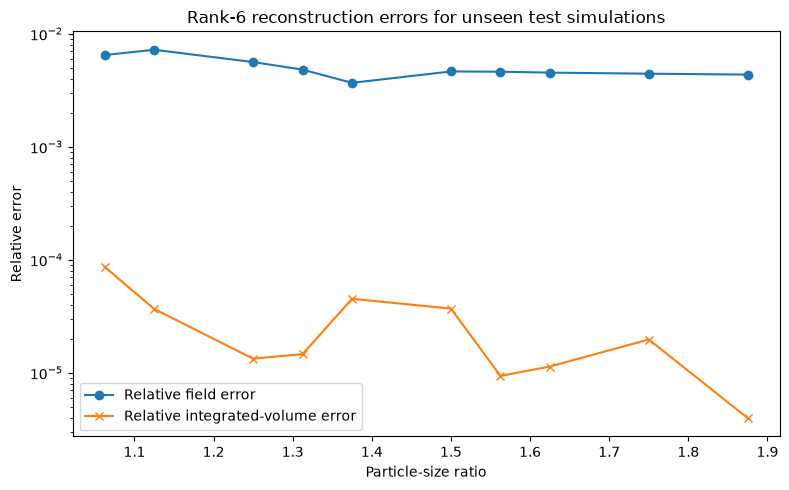

Saved figure:
/Users/rallen/Documents/msc-rom-particle-systems/results/figures/cg_phi_rank6_errors_by_parameter.pdf


In [36]:
plt.figure(
    figsize=(8, 5)
)

plt.semilogy(
    rank_six_diagnostics[
        "size_ratio"
    ],
    rank_six_diagnostics[
        "relative_field_error"
    ],
    marker="o",
    label="Relative field error",
)

plt.semilogy(
    rank_six_diagnostics[
        "size_ratio"
    ],
    rank_six_diagnostics[
        "relative_volume_error"
    ],
    marker="x",
    label="Relative integrated-volume error",
)

plt.xlabel(
    "Particle-size ratio"
)

plt.ylabel(
    "Relative error"
)

plt.title(
    "Rank-6 reconstruction errors "
    "for unseen test simulations"
)

plt.legend()
plt.tight_layout()

parameter_error_figure_path = (
    FIGURE_DIR
    / "cg_phi_rank6_errors_by_parameter.pdf"
)

plt.savefig(
    parameter_error_figure_path,
    bbox_inches="tight",
)

plt.show()

print("Saved figure:")
print(parameter_error_figure_path)

In [37]:
negative_tolerances = [
    0.0,
    -1e-8,
    -1e-6,
    -1e-5,
    -1e-4,
]

print("Negative-value diagnostics by tolerance")
print("---------------------------------------")

for tolerance in negative_tolerances:
    fractions = np.mean(
        reconstructed_test_snapshots < tolerance,
        axis=0,
    )

    print(
        f"Values below {tolerance:.0e}: "
        f"mean fraction = {fractions.mean():.6e}, "
        f"maximum fraction = {fractions.max():.6e}"
    )

maximum_negative_magnitude = abs(
    min(
        reconstructed_test_snapshots.min(),
        0.0,
    )
)

maximum_physical_value = (
    test_snapshot_matrix.max()
)

relative_negative_magnitude = (
    maximum_negative_magnitude
    / maximum_physical_value
)

print(
    "\nLargest negative magnitude:",
    f"{maximum_negative_magnitude:.6e}",
)

print(
    "Largest physical test value:",
    f"{maximum_physical_value:.6e}",
)

print(
    "Negative magnitude relative to physical maximum:",
    f"{relative_negative_magnitude:.6e}",
)

if maximum_negative_magnitude < 1e-4:
    print(
        "\nConclusion: negative values are numerically tiny "
        "and do not presently require clipping."
    )
else:
    warnings.warn(
        "Negative reconstruction values may be physically significant."
    )

Negative-value diagnostics by tolerance
---------------------------------------
Values below 0e+00: mean fraction = 3.024000e-02, maximum fraction = 5.770000e-02
Values below -1e-08: mean fraction = 1.734000e-02, maximum fraction = 4.450000e-02
Values below -1e-06: mean fraction = 1.730000e-03, maximum fraction = 1.080000e-02
Values below -1e-05: mean fraction = 2.000000e-05, maximum fraction = 2.000000e-04
Values below -1e-04: mean fraction = 0.000000e+00, maximum fraction = 0.000000e+00

Largest negative magnitude: 1.165410e-05
Largest physical test value: 5.368250e-01
Negative magnitude relative to physical maximum: 2.170931e-05

Conclusion: negative values are numerically tiny and do not presently require clipping.


## Conclusions

The supplied coarse-grained rotating-drum dataset contains 100 training
simulations and 10 held-out test simulations. The particle-size ratio varies
from 1.0 to 2.0 in the training set, while none of the test parameter values
appear exactly in the training data.

Each simulation provides a time-averaged particle volume-fraction field on a
uniform 100 by 100 spatial grid. All snapshots use the same coordinates,
contain finite values and have physically plausible volume fractions between
zero and approximately 0.54.

The spatial mean of the volume fraction is almost constant across the
simulations, indicating that the amount of material is conserved while its
distribution inside the rotating drum changes with particle-size ratio. The
largest parameter-dependent variation occurs around the free-surface and
internal transition regions.

Both uncentred and mean-centred POD were examined. The uncentred first mode is
dominated by the mean drum field. Mean-centred POD therefore provides the more
interpretable formulation:

$$
\phi(\mu)
\approx
\overline{\phi}
+
\sum_{i=1}^{r}
a_i(\mu)\psi_i.
$$

Six mean-centred POD modes capture at least 99.9% of the fluctuation energy.
Using a basis constructed from training simulations only, the rank-six model
achieves:

- mean unseen test projection error of approximately 0.50%;
- maximum unseen test projection error of approximately 0.72%;
- mean integrated-volume error below 0.003%;
- maximum integrated-volume error below 0.009%.

The largest reconstruction errors are concentrated around steep interfaces,
where small spatial displacements produce comparatively large pointwise
differences. The reconstructed fields contain some slightly negative values
in nominally empty regions, but their magnitude is approximately
10<sup>−5</sup> and is negligible relative to the physical volume-fraction
scale.

The dataset loader, grid validation, snapshot construction and preliminary POD
analysis are therefore working correctly. The next stage is to model the
parameter-to-coefficient relationship and predict complete fields without
projecting known test snapshots onto the POD basis.